In [1]:
import pathlib as path
import pandas as pd
import numpy as np
import os
from datetime import datetime, timedelta
from fnmatch import fnmatch
from typing import Iterable
import xarray as xr
import matplotlib.pyplot as plt
from scipy.stats import norm
import re

In [2]:
def find_nc_fnames(dir_path: str) -> list[str]:
    """
    find_flight_fnames just searches a directory for all *.nc files and returns a list of them.
    
    :param dir_path: a path to the directory containing flight netcdf files
    
    :return: Returns a list of flight netcdf files.
    """
    nc_paths=[]
    nc_fnames = sorted([fname for fname in os.listdir(dir_path) if fnmatch(fname, "*.nc")])
    for i in range(len(nc_fnames)):
        nc_paths.append(dir_path + '/' + nc_fnames[i])
        
        nudg_path = [file for file in nc_paths if ".hs." in file]
        free_path = [file for file in nc_paths if ".h0." in file]
        # save dictionary with the paths for 
        model_paths = {'Free': free_path,'Nudg': nudg_path}
        
    return model_paths

def open_nc(paths: str) -> xr.open_dataset:
    """
    open_flight_nc simply checks to see if the file at the provided path string exists and opens it.

    :param file_path: A path string to a flight data file, e.g. "./test/test_flight.nc"

    :return: Returns xr.open_dataset object.
    """

    nc_path = path.Path(paths)
    if not nc_path.is_file():
        raise FileNotFoundError('testing excptions')

    return xr.open_dataset(paths)
    
def find_sondes(dir_path: str) -> list[str]:
    """
    find_sondes just searches a directory for all *.cls files and returns a list of them.

    :param dir_path: a path to the directory containing flight netcdf files

    :return: Returns a list of flight netcdf files.
    """
    flight_paths=[]
    flight_fnames = sorted([fname for fname in os.listdir(dir_path) if fnmatch(fname, "*.cls")])
    for i in range(len(flight_fnames)):
        flight_paths.append(dir_path + '/' + flight_fnames[i])
    
    return flight_paths

def read_sonde2df(file_path: str) -> tuple[list[pd.DataFrame], list[pd.Timestamp]]:
    """
    Reads a `.cls` radiosonde file and extracts multiple datasets with their nominal release times.

    :param file_path: Path to the `.cls` file containing radiosonde data.

    :return: A tuple containing:
        - A list of Pandas DataFrames, each representing an individual radiosonde dataset.
        - A list of corresponding nominal release times as Pandas Timestamps.
    
    :raises FileNotFoundError: If the file does not exist.
    :raises ValueError: If the file is incorrectly formatted or missing essential data.
    """
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File '{file_path}' not found.")

    # Read the entire file into memory
    with open(file_path, "r", encoding="utf-8") as file:
        lines = file.readlines()

    # Identify all "Nominal Release Time" occurrences
    start_indices = [i for i, line in enumerate(lines) if "Nominal Release Time" in line]
    
    if not start_indices:
        raise ValueError(f"No 'Nominal Release Time' entries found in file: {file_path}")

    datasets = []
    drop_times = []

    # Process each radiosonde dataset
    for idx, start in enumerate(start_indices):
        # Find the start of the tabular data
        data_start = None
        for i in range(start, len(lines) - 2):
            if lines[i].strip().startswith("Time") and "Press" in lines[i]:  # Detect header row
                data_start = i + 3  # Data starts 2 lines after the column names
                break

        if data_start is None:
            print(f"Warning: No data start found for entry at line {start}")
            continue  # Skip this dataset

        # Extract and convert nominal release time
        try:
            date_time_str = lines[start].split("):")[1].strip()
            drop_time = pd.to_datetime(date_time_str, format='%Y, %m, %d, %H:%M:%S')
        except (IndexError, ValueError) as e:
            print(f"Warning: Failed to parse drop time at line {start}: {e}")
            continue  # Skip this dataset

        drop_times.append(drop_time)

        # Extract column names
        columns = lines[data_start - 3].strip().split()

        # Determine dataset end (next "Nominal Release Time" or end of file)
        end = start_indices[idx + 1] if idx + 1 < len(start_indices) else len(lines)

        # Extract and clean data
        data_lines = [line.strip().split() for line in lines[data_start:end]]
        data = [row for row in data_lines if len(row) == len(columns)]

        # Convert to DataFrame
        df = pd.DataFrame(data, columns=columns)

        if df.empty:
            print(f"Warning: Empty dataset at line {start}")
            continue  # Skip empty datasets

        # Remove rows containing 9999.0 in any column
        df = df[(df != "9999.0").all(axis=1)]
        # Convert the 'Lat' column to numeric if it's not already
        df['Lat'] = pd.to_numeric(df['Lat'], errors='coerce')

        # Remove rows where 'lat' equals 999.0
        df = df[df['Lat'] != 999.0]

        # Convert numeric columns where possible
        df = df.apply(pd.to_numeric, errors='coerce')

        # Store drop time in DataFrame metadata
        df.attrs["drop_time"] = drop_time
        # Append dataset
        datasets.append(df)
        # datasets.attr

    return datasets#, drop_times


In [19]:
dir = '/Users/patnaude/Documents/Data/SOCRATES/Dropsonde'

paths = find_sondes(dir)
file= paths[3]
dfs = read_sonde2df(file)
# df = dfs[0]  # Get the first dataset

cesm_dir = '/Users/patnaude/Documents/Data/cesmdata'

cesm_files = find_nc_fnames(cesm_dir)
# cesm_files['Nudg'][0]
cesm_ndg = open_nc(cesm_files['Nudg'][0])
cesm = open_nc(cesm_files['Free'][0])
# np.max(df['Lon'])
dfs[0].attrs
# print(len(dfs))

{'drop_time': Timestamp('2018-01-24 00:03:49')}

In [20]:
def find_flight_fnames(dir_path: str) -> list[str]:
    """
    find_flight_fnames just searches a directory for all *.nc files and returns a list of them.

    :param dir_path: a path to the directory containing flight netcdf files

    :return: Returns a list of flight netcdf files.
    """
    flight_paths=[]
    flight_fnames = sorted([fname for fname in os.listdir(dir_path) if fnmatch(fname, "*.nc")])
    for i in range(len(flight_fnames)):
        flight_paths.append(dir_path + '/' + flight_fnames[i])
    
    return flight_paths

# Function to read in all the relevant variables from the NSF aircraft datasets
def read_vars(nc):

    var_list = nc.data_vars
    time = 'Time'
    # Spatial variables
    lat, lon, alt = 'GGLAT', 'GGLON', 'GGALT'
    
    # state variables
    temp = 'ATX'
    dwpt = 'DPXC'
    u = 'UIC' if 'UIC' in var_list else 'UIX'
    v = 'VIC' if 'VIC' in var_list else 'VIX'
    w = 'WIC' if 'WIC' in var_list else 'WIX'
    p = 'PSXC'
    ew = 'EWX'
    rh = 'RHUM'
    vars_to_read = [time, lat, lon, alt, temp, dwpt, u,  w, p, ew, rh]
    # Thermodynamic data
    if any('THETA' in var for var in var_list): 
        theta_vars = [var for var in var_list if 'THETA' in var]
        vars_to_read.extend(theta_vars)
    # Cloud microphysical
    if any('CONC' in var for var in var_list): # cloud concentrations
        conc_vars = [var for var in var_list if 'CONC' in var and 'D' in var and('_2' not in var and 'R_' not in var and 'CN' not in var)]
        # print(conc_vars)
        vars_to_read.extend(conc_vars)
    if any('PLW' in var for var in var_list): # Liquid/Ice water contents
        # v = [var for var in var_list if '2' not in var]
        wc_vars = [var for var in var_list if 'PLW' in var and '_2' not in var]
        vars_to_read.extend(wc_vars)
    # Aerosol data
    if any('UHSAS' in var for var in var_list) or any('CONCN' in var for var in var_list):
        aer_var = [var for var in var_list if ('UHSAS' in var or 'CONCU' in var or 'CONCN' in var) and ('AU' not in var and 'UD' not in var and 'CUH' not in var)]
        uhsas_cells = var_list['CUHSAS_LWII'].CellSizes
        # print(aer_var)
        vars_to_read.extend(aer_var)
    return vars_to_read

def read_flight_nc_1hz(nc: xr.open_dataset, read_vars: list[str]) -> pd.DataFrame:
    """
    read_flight_nc reads a set of variables into memory.

    NOTE: a low-rate, 1 Hz, flight data file is assumed

    :param nc: netCDF4._netCDF4.Dataset object opened by open_flight_nc.
    :param read_vars: An optional list of strings of variable names to be read into memory. A default
                      list, vars_to_read, is specified above. Passing in a similar list will read in those variables
                      instead.

    :return: Returns a pandas data frame.
    """

    data = [] # an empty list to accumulate Dataframes of each variable to be read in
    long_names = [nc[var].long_name if 'long_name' in nc[var].attrs else None for var in read_vars]
    for var in read_vars:
        try:
            if var == "Time":
                # time is provided every second, so need to calculate 25 Hz times efficiently
                # tunits = getattr(nc[var],'units')
                # df = xr.open_dataset(nc)
                time = np.array(nc.Time)
                data.append(pd.DataFrame({var: time}))
                # dt_list = sfm_to_datetime(time, tunits)
                # data.append(pd.DataFrame({'datetime': time}))
            else:
                output = nc[var][:]
                data.append(pd.DataFrame({var: output}))
        except Exception as e:
            print(f"Issue reading {var}: {e}")
            pass

    dataframe = pd.concat(data, axis=1, ignore_index=False)
    dataframe.attrs['long_names'] = long_names
    # concatenate the list of dataframes into a single dataframe and return it
    return dataframe
    

dir = '/Users/patnaude/Documents/Data/SOCRATES'
flight_paths = find_flight_fnames(dir)
# flight_paths

nc = open_nc(flight_paths[4])
vars_to_read = read_vars(nc)

df = read_flight_nc_1hz(nc,vars_to_read)
df

,Time,GGLAT,GGLON,GGALT,ATX,DPXC,UIC,WIC,PSXC,EWX,...,PLWC2DCR_RWOI,PLWCC,PLWCD_RWIO,CONCN,CONCU100_CVIU,CONCU100_LWII,CONCU500_CVIU,CONCU500_LWII,CONCU_CVIU,CONCU_LWII
0,2018-01-25 22:50:00,-42.832363,147.506638,7.12864,19.968699,10.242052,0.0,0.0,1012.212036,12.484764,...,0.0,NaN,0.0,2638.470215,0.0,110.612091,0.0,1.271403,0.000000,228.852600
1,2018-01-25 22:50:01,-42.832310,147.506577,7.13092,19.920820,10.283250,0.0,0.0,1012.200195,12.519177,...,0.0,NaN,0.0,2707.998535,0.0,117.708679,0.0,1.265685,0.000000,256.933990
2,2018-01-25 22:50:02,-42.832256,147.506500,7.14859,19.873640,10.244993,0.0,0.0,1012.208191,12.487221,...,0.0,NaN,0.0,4260.188965,0.0,115.563232,0.0,6.349628,1.508146,253.985138
3,2018-01-25 22:50:03,-42.832203,147.506439,7.15260,19.860159,10.296937,0.0,0.0,1012.200806,12.530610,...,0.0,NaN,0.0,4906.379883,0.0,123.514847,0.0,1.273349,1.502170,249.576385
4,2018-01-25 22:50:04,-42.832150,147.506363,7.15254,19.848888,10.308925,0.0,0.0,1012.200195,12.540624,...,0.0,NaN,0.0,7610.107910,0.0,116.831924,0.0,5.079649,0.000000,248.902786
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25796,2018-01-26 05:59:56,-42.839355,147.507294,7.42173,26.356476,11.557915,0.0,0.0,1011.876587,13.626041,...,0.0,NaN,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25797,2018-01-26 05:59:57,-42.839355,147.507294,7.42167,26.341032,11.688485,0.0,0.0,1011.852051,13.745115,...,0.0,NaN,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25798,2018-01-26 05:59:58,-42.839355,147.507294,7.42087,26.286243,11.648069,0.0,0.0,1011.852478,13.708258,...,0.0,NaN,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
25799,2018-01-26 05:59:59,-42.839355,147.507294,7.42185,26.245584,NaN,0.0,0.0,1011.856018,NaN,...,0.0,NaN,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [13]:
def grid_sonde(cesm: xr.open_dataset, cesm_dat: xr.open_dataset, dfs: pd.DataFrame) -> dict:   
    # Initialize an empty grid_dict outside the loop to accumulate data
    grid_dict = {} 
    grid_dict['Time'] = np.array([], dtype='datetime64[s]')
    df1 = dfs[0] # use the first df for df_vars
    df_vars = [col for col in df1.columns if col.lower() != 'time']
    grid_dict.update({var: [] for var in df_vars})  # Initialize for all variables
    # Loop through sonde dataframes
    for d in range(len(dfs)):
        df = dfs[d]  # Get the first dataset
        # Step 1: Identify Variables Automatically
        lat_var = next((var for var in df.columns if 'Lat' in var), None)
        lon_var = next((var for var in df.columns if 'Lon' in var), None)
        alt_var = next((var for var in df.columns if 'Press' in var), None)
        
        # Compute pressure altitude (palt) from CESM hybrid coordinates
        p0 = cesm.P0  # Reference pressure
        ps = cesm.PS  # Surface pressure [=] Pa
        hyai = cesm.hyai  # Hybrid A coefficient at layer interface
        hybi = cesm.hybi  # Hybrid B coefficient at layer interface
        
        P_dummy = p0 * hyai
        midP = (P_dummy + (hybi * ps))  # [=] Pa
        palt = midP * 0.01  # Convert to hPa
        
        if not lat_var or not lon_var or not alt_var:
            raise ValueError("Missing essential latitude, longitude, or altitude variables.")
        
        # Step 2: Create a 3D grid based on CESM & flight data
        # Compute midpoints
        lat_mp = (cesm.lat[:-1] + cesm.lat[1:]) / 2
        lon_mp = (cesm.lon[:-1] + cesm.lon[1:]) / 2
        # Find lat & lon bounds based on aircraft min/max values
        lat_bounds = [int(np.abs(lat_mp - np.min(df[lat_var])).argmin()) - 1, 
                      int(np.abs(lat_mp - np.max(df[lat_var])).argmin()) + 1]
        lon_bounds = [int(np.abs(lon_mp - np.min(df[lon_var])).argmin()) - 1, 
                      int(np.abs(lon_mp - np.max(df[lon_var])).argmin()) + 1]
        
        # Ensure bounds are within valid range
        lat_bounds = [max(0, lat_bounds[0]), min(len(lat_mp) - 1, lat_bounds[1])]
        lon_bounds = [max(0, lon_bounds[0]), min(len(lon_mp) - 1, lon_bounds[1])]
        
        # Select the subset of `palt` corresponding to the lat/lon bounds
        palt_subset = palt.isel(lat=slice(lat_bounds[0], lat_bounds[1] + 1),
                                lon=slice(lon_bounds[0], lon_bounds[1] + 1))
        
        # Extract altitude values based on dropsonde altitude range
        min_alt, max_alt = np.min(df[alt_var]), np.max(df[alt_var])
        # Find altitude bounds dynamically for each lat-lon grid cell
        alt_indices = []
        for lat_idx in range(lat_bounds[0], lat_bounds[1] + 1):
            for lon_idx in range(lon_bounds[0], lon_bounds[1] + 1):
                local_palt = palt.isel(lat=lat_idx, lon=lon_idx).values  # Get 1D alt profile for this grid cell
        
                min_alt_idx = np.abs(local_palt - min_alt).argmin()
                max_alt_idx = np.abs(local_palt - max_alt).argmin()
        
                alt_indices.append((min_alt_idx, max_alt_idx))
        
        # Determine overall altitude bounds from all lat-lon cells
        min_alt_bound = min(i[0] for i in alt_indices)
        max_alt_bound = max(i[1] for i in alt_indices)
        
        # Ensure altitude bounds are valid
        alt_bounds = [max(0, min_alt_bound - 1), min(palt.shape[0] - 1, max_alt_bound + 1)]
        # Define bounds dictionary
        bounds = {'lat': lat_bounds, 'lon': lon_bounds, 'palt': alt_bounds}
        
        # Create grid with the correct shape
        grid_shape = (alt_bounds[1] - alt_bounds[0] + 1, 
                      lat_bounds[1] - lat_bounds[0] + 1, 
                      lon_bounds[1] - lon_bounds[0] + 1)
            
        grid = np.zeros(grid_shape)
        
        # Step 3: Match aircraft times with CESM times
        da = xr.DataArray(cesm_ndg.time, dims="time")
        cesm_times = pd.to_datetime([pd.Timestamp(dt.year, dt.month, dt.day, dt.hour, dt.minute, dt.second)
                            for dt in da.values])    
        
        # Convert drop_time attribute to datetime
        drop_time = pd.to_datetime(df.attrs['drop_time'])
        
        # Convert 'Time' column (assuming it's in seconds) to timedelta
        df['Real_time'] = drop_time + pd.to_timedelta(df['Time'], unit='s')
        df = df.sort_values(by='Real_time', ascending=True).reset_index(drop=True)
        
        # Step 4: Initialize grid arrays
        mean_lat, mean_lon, mean_alt = np.zeros_like(grid, dtype=float), np.zeros_like(grid, dtype=float), np.zeros_like(grid, dtype=float)
        
        mean_values = {var: np.zeros_like(grid, dtype=float) for var in df_vars}
        mean_lat, mean_lon, mean_alt = np.zeros_like(grid, dtype=float), np.zeros_like(grid, dtype=float), np.zeros_like(grid, dtype=float)
        
        # # Generate latitude, longitude grid values
        lats = np.array(lat_mp[bounds['lat'][0]:bounds['lat'][1] + 1])
        lons = np.array(lon_mp[bounds['lon'][0]:bounds['lon'][1] + 1])
            
        # # Select the region of interest in `palt`
        palt_subset = palt.sel(lat=slice(lats.min(), lats.max()), lon=slice(lons.min(), lons.max()))
        
        mid_time = []
        
        lat_bins = np.digitize(df['Lat'], lats) - 1
        lon_bins = np.digitize(df['Lon'], lons) - 1
        
        # Ensure valid lat/lon indices
        valid_mask = (lat_bins >= 0) & (lat_bins < len(lats) - 1) & \
                     (lon_bins >= 0) & (lon_bins < len(lons) - 1)
        
        if valid_mask.any():
            # Filter valid rows
            sliced_df = df.loc[valid_mask].copy()
            sliced_df['lat_bin'] = lat_bins[valid_mask]
            sliced_df['lon_bin'] = lon_bins[valid_mask]
        
            # Compute altitude bins dynamically based on (lat_bin, lon_bin)
            alt_bins = np.full(len(sliced_df), -1, dtype=int)  # Initialize invalid bins
        
            for i, (lat_idx, lon_idx, psxc) in enumerate(zip(sliced_df['lat_bin'], sliced_df['lon_bin'], sliced_df['Press'])):
                # Extract altitude levels for this (lat_idx, lon_idx) from `palt`
                local_alt_profile = palt_subset.isel(lat=lat_idx, lon=lon_idx).values  # Keep natural order
                local_alt_profile = local_alt_profile.squeeze()
                # Reverse the altitude profile so that it corresponds to the correct pressure (high to low)
                local_alt_profile = local_alt_profile[::-1]
                # Use np.searchsorted to find the correct bin, but ensure no index out of range
                bin_idx = np.digitize(psxc, local_alt_profile, right=True) - 1     
                # Check for out-of-bounds indices
                if bin_idx < 0:
                    print(f"Warning: Pressure {psxc} not in range for lat_idx={lat_idx}, lon_idx={lon_idx}")
                    alt_bins[i] = -1  # Mark as invalid
                else:
                    alt_bins[i] = bin_idx
        
            # Assign altitude bins
            sliced_df['alt_bin'] = alt_bins
        
            # Ensure valid altitude indices
            valid_alt_mask = (alt_bins >= 0) & (alt_bins < palt.shape[0] - 1)
            sliced_df = sliced_df[valid_alt_mask]
            # Group by grid cells and compute means                
            grouped = sliced_df.groupby(['alt_bin', 'lat_bin', 'lon_bin'])
            for var in df_vars:
        
                grouped_mean = grouped[var].mean()
                # print(grouped_mean)
                if not grouped_mean.empty:  # ✅ Skip empty bins
                    mean_values[var][tuple(zip(*grouped_mean.index.to_numpy()))] = grouped_mean.values
                    # print(grouped_mean.values)
                    mean_lat[tuple(zip(*grouped[lat_var].mean().index.to_numpy()))] = grouped[lat_var].mean().values
                    mean_lon[tuple(zip(*grouped[lon_var].mean().index.to_numpy()))] = grouped[lon_var].mean().values
                    mean_alt[tuple(zip(*grouped[alt_var].mean().index.to_numpy()))] = grouped[alt_var].mean().values
        
            # Compute mid-time for each grid cell
            grouped_times = grouped['Real_time'].agg(lambda x: x.min() + (x.max() - x.min()) / 2)
            mid_time.extend(grouped_times.values)
        
        # Convert mid_time to NumPy array
        mid_time = np.array(mid_time, dtype='datetime64[s]')        
        mean_t = mean_values['Temp']
        valid_indices = np.argwhere(mean_t != 0)
        if valid_indices.size > 0:
            # Inside the loop
            selected_time = mid_time[:len(valid_indices)].astype('datetime64[s]')  # Round to nearest second
            grid_dict['Time'] = np.concatenate((grid_dict['Time'], selected_time))  # Append as numpy array
    
            for var in df_vars:
                selected_data = mean_values[var][mean_t != 0].flatten()
                # print(f"Iteration {d}, {var} size before appending: {selected_data.size}")
    
                if selected_data.size > 0:
                    grid_dict[var].extend(selected_data.tolist())    
            
        # grid_dict.update({var: mean_values[var][mean_t != 0] for var in df_vars})
    
    # Get sorted indices
    sorted_indices = np.argsort(selected_time)
    # Apply sorted indices to all dictionary values
    # grid_dict = {key: np.array(value)[sorted_indices] for key, value in grid_dict.items()}
    # grid_dict.update({'long_names':  df.attrs['long_names']})
    
    # Confirm the dictionary has data
    if all(len(v) > 0 for v in grid_dict.values()):
        print("✅ Grid dictionary successfully populated with data!")
    else:
        print("⚠️ Warning: Some entries in grid_dict are empty!")

    return grid_dict
# grid_dict



✅ Grid dictionary successfully populated with data!


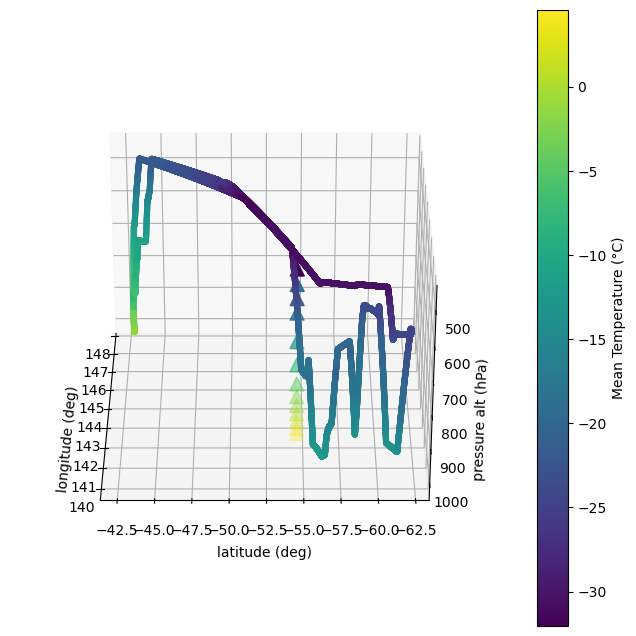

In [14]:
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation  

# grid_data = grid_flight_dat(cesm_fr, cesm_ndg, df, nc)
grid_data = grid_sonde(cesm, cesm_ndg, dfs)
# print(grid_data)
# Create a figure
fig = plt.figure(figsize=(8, 8))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
sc = ax.scatter(grid_data['Lon'], grid_data['Lat'], grid_data['Press'], c=grid_data['Temp'], cmap='viridis', marker='^',label='grid-mean values',s=100)
# Invert the Z-axis
# for i in range(len(dfs)):
ax.scatter(df['GGLON'], df['GGLAT'], df['PSXC'], c=df['ATX'], label='Dropsonde data',s=12)
ax.invert_zaxis()

ax.set_ylabel('latitude (deg)')
ax.set_xlabel('longitude (deg)')
ax.set_zlabel('pressure alt (hPa)') 
# Set limits for latitude and longitude axes
# ax.set_xlim(148, 150)  # Latitude range
# ax.set_ylim(-48, -44)  # Longitude range

# ax.legend()
# # Color bar to show the mapping of color to the fourth dimension
plt.colorbar(sc, label='Mean Temperature (°C)')

# Animation function to rotate the view
def rotate(angle):
    ax.view_init(elev=30, azim=angle)

# Create animation
ani = FuncAnimation(fig, rotate, frames=np.arange(-180, 360, 20), interval=100)

# Show the animation in Jupyter Notebook
from IPython.display import HTML
HTML(ani.to_jshtml())
# Labels


# # Show the plot
# plt.show()